<a href="https://colab.research.google.com/github/nicholasemccormick/colossal-ai-consulting/blob/main/No_show_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lightgbm shap imbalanced-learn --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay, average_precision_score
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted')
print('✅ All imports successful')

✅ All imports successful


In [3]:
N = 5000

# --- Patient-level features ---
patient_ids = np.random.randint(1000, 9999, N)
ages = np.random.choice(
    range(18, 85),
    size=N,
    p=np.array([1/(85-18)] * (85-18)) / np.sum([1/(85-18)] * (85-18))
)
genders = np.random.choice(['M', 'F'], size=N, p=[0.45, 0.55])

insurance_types = np.random.choice(
    ['Commercial', 'Medicaid', 'Medicare', 'Self-Pay', 'Other'],
    size=N,
    p=[0.40, 0.25, 0.20, 0.10, 0.05]
)

# Distance from practice in miles (zip code proxy)
distance_miles = np.random.exponential(scale=8, size=N).clip(0.5, 60).round(1)

# Historical no-show count (most predictive single feature in literature)
prior_no_shows = np.random.choice(
    [0, 1, 2, 3, 4, 5],
    size=N,
    p=[0.55, 0.22, 0.12, 0.06, 0.03, 0.02]
)

# Total prior appointments (tenure)
prior_appointments = prior_no_shows + np.random.randint(0, 20, N)

# Historical cancellation count
prior_cancellations = np.random.choice([0, 1, 2, 3], size=N, p=[0.60, 0.25, 0.10, 0.05])

# --- Appointment-level features ---
appt_types = np.random.choice(
    ['New Patient', 'Follow-Up', 'Annual Wellness', 'Sick Visit', 'Procedure'],
    size=N,
    p=[0.15, 0.40, 0.20, 0.18, 0.07]
)

# Lead time in days (days between booking and appointment)
lead_time_days = np.random.choice(
    [0, 1, 2, 3, 7, 14, 21, 30, 45, 60, 90],
    size=N,
    p=[0.05, 0.08, 0.08, 0.10, 0.15, 0.15, 0.12, 0.12, 0.08, 0.05, 0.02]
)

# Day of week (0=Monday)
day_of_week = np.random.choice(range(5), size=N, p=[0.22, 0.21, 0.20, 0.20, 0.17])
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

# Hour of appointment
appt_hour = np.random.choice(
    range(8, 18),
    size=N,
    p=[0.08, 0.12, 0.12, 0.10, 0.08, 0.10, 0.10, 0.10, 0.10, 0.10]
)

# Holiday proximity flag (day before or after a major holiday)
near_holiday = np.random.choice([0, 1], size=N, p=[0.88, 0.12])

# Reminder sent flag (was a reminder sent before this appointment?)
reminder_sent = np.random.choice([0, 1], size=N, p=[0.35, 0.65])

# Provider (some providers have better retention than others)
providers = np.random.choice(['Dr. Smith', 'Dr. Patel', 'Dr. Johnson', 'NP Williams'], size=N, p=[0.30, 0.28, 0.25, 0.17])

# --- Label Generation ---
# Base no-show probability ~18%, adjusted by known risk factors
base_prob = 0.18

no_show_prob = (
    base_prob
    + (prior_no_shows * 0.07)                                          # history is strongest signal
    + (prior_cancellations * 0.04)
    + (lead_time_days > 14) * 0.06                                     # longer lead = higher risk
    + (lead_time_days > 30) * 0.05
    + np.where(insurance_types == 'Medicaid', 0.08, 0)                 # structural barriers
    + np.where(insurance_types == 'Self-Pay', 0.06, 0)
    + np.where(appt_types == 'New Patient', 0.05, 0)                   # new patients less committed
    + np.where(day_of_week == 0, 0.04, 0)                              # Monday effect
    + np.where(day_of_week == 4, 0.03, 0)                              # Friday effect
    + (distance_miles > 20) * 0.04
    + near_holiday * 0.05
    - reminder_sent * 0.06                                              # reminders help
    - np.where(appt_types == 'Annual Wellness', 0.03, 0)               # wellness appts more committed
    + np.random.normal(0, 0.05, N)                                     # noise
).clip(0.01, 0.95)

no_show = (np.random.uniform(0, 1, N) < no_show_prob).astype(int)

# --- Assemble DataFrame ---
df = pd.DataFrame({
    'patient_id': patient_ids,
    'age': ages,
    'gender': genders,
    'insurance_type': insurance_types,
    'distance_miles': distance_miles,
    'prior_no_shows': prior_no_shows,
    'prior_appointments': prior_appointments,
    'prior_cancellations': prior_cancellations,
    'appt_type': appt_types,
    'lead_time_days': lead_time_days,
    'day_of_week': day_of_week,
    'day_name': [day_names[d] for d in day_of_week],
    'appt_hour': appt_hour,
    'near_holiday': near_holiday,
    'reminder_sent': reminder_sent,
    'provider': providers,
    'no_show': no_show
})

print(f'Dataset shape: {df.shape}')
print(f'No-show rate: {df.no_show.mean():.1%}')
df.head()

Dataset shape: (5000, 17)
No-show rate: 30.3%


,patient_id,age,gender,insurance_type,distance_miles,prior_no_shows,prior_appointments,prior_cancellations,appt_type,lead_time_days,day_of_week,day_name,appt_hour,near_holiday,reminder_sent,provider,no_show
0,8270,75,F,Medicaid,7.2,0,12,0,Sick Visit,0,4,Friday,8,0,0,NP Williams,0
1,1860,51,M,Commercial,5.3,0,2,0,Follow-Up,14,4,Friday,9,0,0,Dr. Johnson,0
2,6390,63,M,Self-Pay,30.5,0,1,0,Annual Wellness,14,0,Monday,15,0,0,Dr. Johnson,0
3,6191,34,M,Medicaid,15.0,0,8,0,New Patient,3,2,Wednesday,11,0,0,Dr. Smith,0
4,6734,68,M,Self-Pay,4.9,0,6,0,Follow-Up,30,4,Friday,8,0,0,Dr. Smith,1


In [4]:
# Dataset overview
print('=== Dataset Info ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Target Distribution ===')
print(df.no_show.value_counts())
print(f'\nNo-show rate: {df.no_show.mean():.1%}')

=== Dataset Info ===
patient_id               int64
age                      int64
gender                  object
insurance_type          object
distance_miles         float64
prior_no_shows           int64
prior_appointments       int64
prior_cancellations      int64
appt_type               object
lead_time_days           int64
day_of_week              int64
day_name                object
appt_hour                int64
near_holiday             int64
reminder_sent            int64
provider                object
no_show                  int64
dtype: object

=== Missing Values ===
patient_id             0
age                    0
gender                 0
insurance_type         0
distance_miles         0
prior_no_shows         0
prior_appointments     0
prior_cancellations    0
appt_type              0
lead_time_days         0
day_of_week            0
day_name               0
appt_hour              0
near_holiday           0
reminder_sent          0
provider               0
no_show       

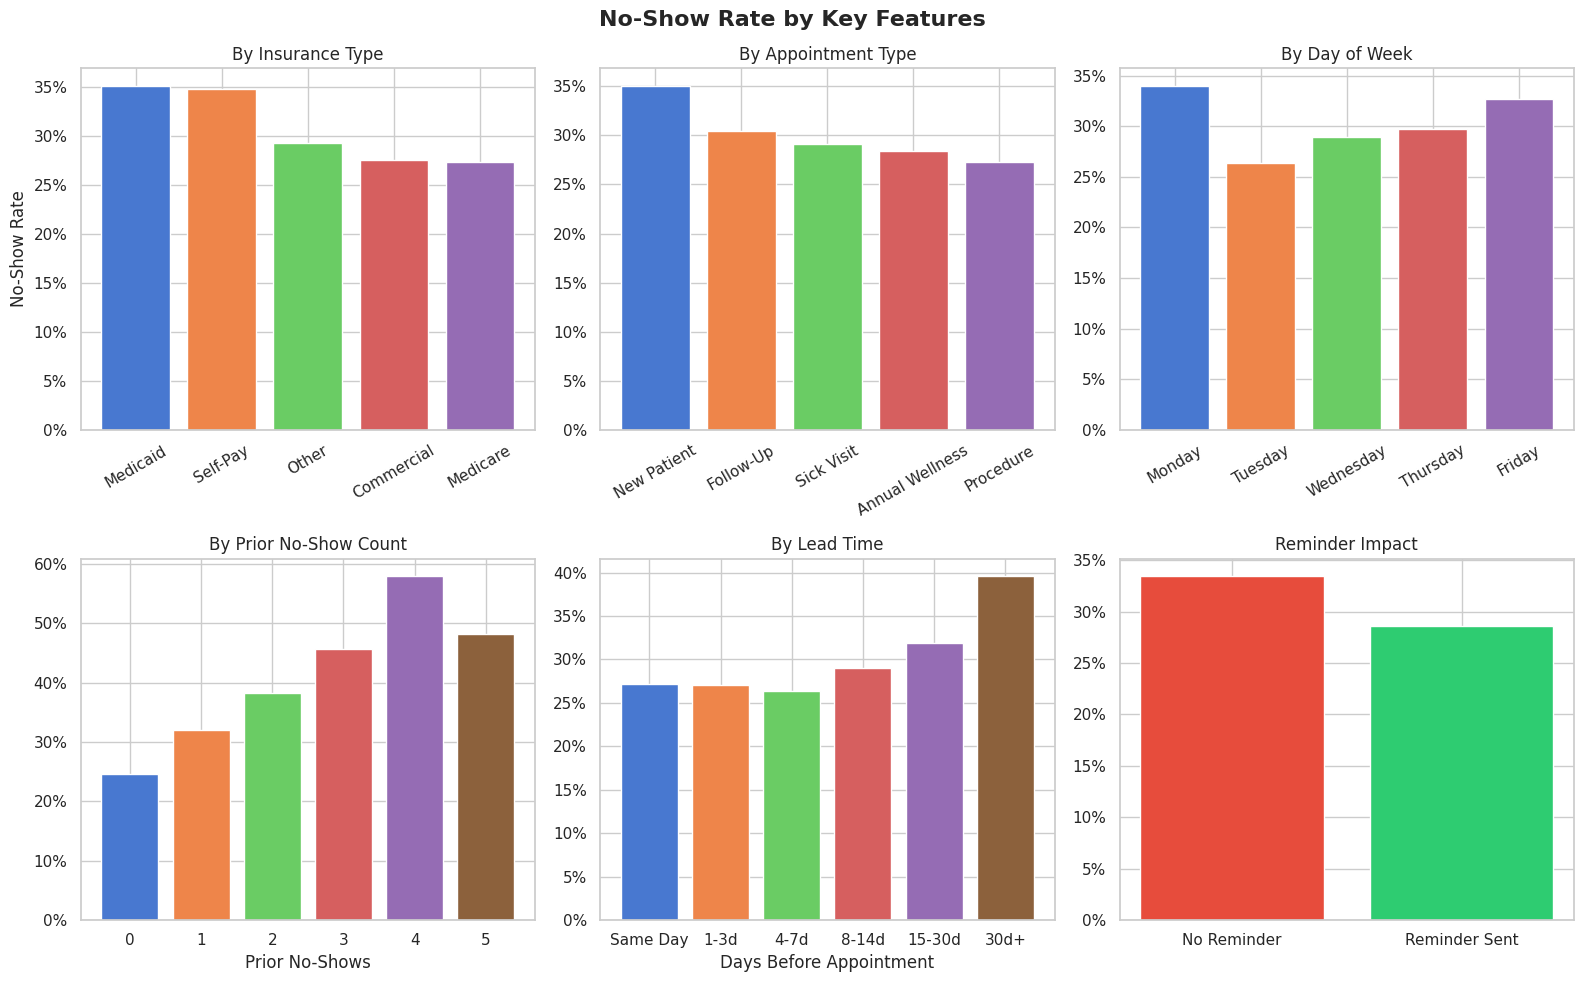

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('No-Show Rate by Key Features', fontsize=16, fontweight='bold')

# No-show by insurance type
ins_rate = df.groupby('insurance_type')['no_show'].mean().sort_values(ascending=False)
axes[0,0].bar(ins_rate.index, ins_rate.values, color=sns.color_palette('muted'))
axes[0,0].set_title('By Insurance Type')
axes[0,0].set_ylabel('No-Show Rate')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# No-show by appointment type
appt_rate = df.groupby('appt_type')['no_show'].mean().sort_values(ascending=False)
axes[0,1].bar(appt_rate.index, appt_rate.values, color=sns.color_palette('muted'))
axes[0,1].set_title('By Appointment Type')
axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# No-show by day of week
day_rate = df.groupby('day_name')['no_show'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday'])
axes[0,2].bar(day_rate.index, day_rate.values, color=sns.color_palette('muted'))
axes[0,2].set_title('By Day of Week')
axes[0,2].tick_params(axis='x', rotation=30)
axes[0,2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# No-show by prior no-shows
prior_rate = df.groupby('prior_no_shows')['no_show'].mean()
axes[1,0].bar(prior_rate.index, prior_rate.values, color=sns.color_palette('muted'))
axes[1,0].set_title('By Prior No-Show Count')
axes[1,0].set_xlabel('Prior No-Shows')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# No-show by lead time bucket
df['lead_bucket'] = pd.cut(df.lead_time_days, bins=[-1,0,3,7,14,30,100], labels=['Same Day','1-3d','4-7d','8-14d','15-30d','30d+'])
lead_rate = df.groupby('lead_bucket', observed=True)['no_show'].mean()
axes[1,1].bar(lead_rate.index.astype(str), lead_rate.values, color=sns.color_palette('muted'))
axes[1,1].set_title('By Lead Time')
axes[1,1].set_xlabel('Days Before Appointment')
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Reminder impact
reminder_rate = df.groupby('reminder_sent')['no_show'].mean()
axes[1,2].bar(['No Reminder', 'Reminder Sent'], reminder_rate.values, color=['#e74c3c', '#2ecc71'])
axes[1,2].set_title('Reminder Impact')
axes[1,2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

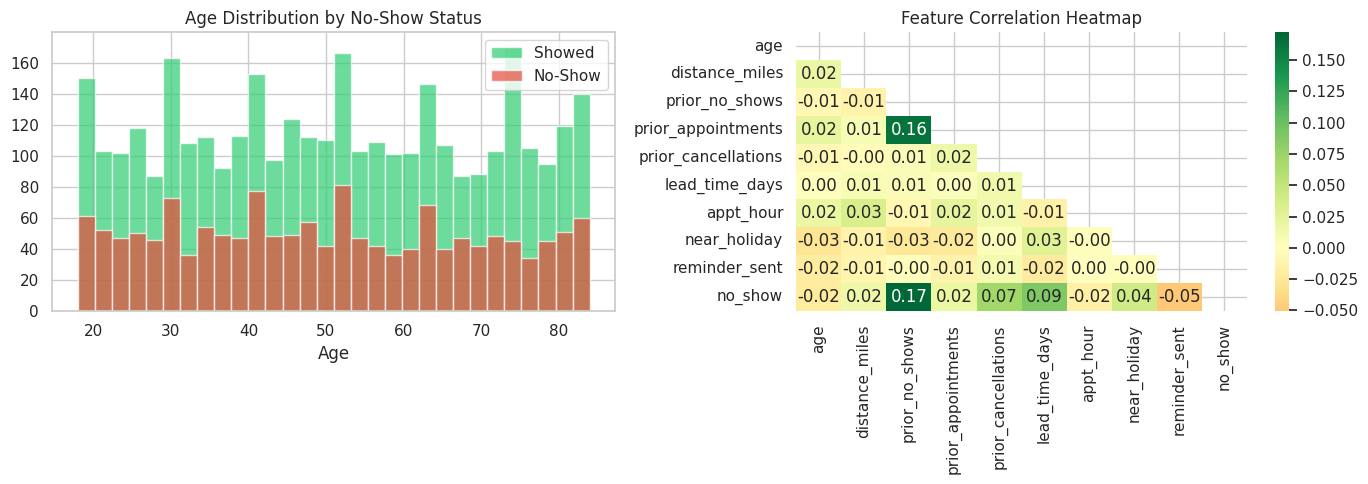

In [6]:
# Age distribution by no-show status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df.no_show==0]['age'].hist(bins=30, ax=axes[0], color='#2ecc71', alpha=0.7, label='Showed')
df[df.no_show==1]['age'].hist(bins=30, ax=axes[0], color='#e74c3c', alpha=0.7, label='No-Show')
axes[0].set_title('Age Distribution by No-Show Status')
axes[0].set_xlabel('Age')
axes[0].legend()

# Correlation heatmap (numeric only)
numeric_cols = ['age', 'distance_miles', 'prior_no_shows', 'prior_appointments',
                'prior_cancellations', 'lead_time_days', 'appt_hour', 'near_holiday',
                'reminder_sent', 'no_show']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1], center=0)
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

In [7]:
df_model = df.copy()

# Derived features
df_model['no_show_rate_historical'] = (
    df_model['prior_no_shows'] / (df_model['prior_appointments'] + 1)
).round(3)  # avoid div/0

df_model['is_monday'] = (df_model['day_of_week'] == 0).astype(int)
df_model['is_friday'] = (df_model['day_of_week'] == 4).astype(int)
df_model['is_morning'] = (df_model['appt_hour'] < 12).astype(int)
df_model['is_new_patient'] = (df_model['appt_type'] == 'New Patient').astype(int)
df_model['high_lead_time'] = (df_model['lead_time_days'] > 14).astype(int)
df_model['far_from_practice'] = (df_model['distance_miles'] > 20).astype(int)
df_model['repeat_offender'] = (df_model['prior_no_shows'] >= 2).astype(int)

# Encode categoricals
le = LabelEncoder()
for col in ['gender', 'insurance_type', 'appt_type', 'provider']:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])

# Define feature set
FEATURES = [
    'age', 'gender_enc', 'insurance_type_enc', 'distance_miles',
    'prior_no_shows', 'prior_appointments', 'prior_cancellations',
    'no_show_rate_historical', 'appt_type_enc', 'lead_time_days',
    'day_of_week', 'appt_hour', 'near_holiday', 'reminder_sent',
    'provider_enc', 'is_monday', 'is_friday', 'is_morning',
    'is_new_patient', 'high_lead_time', 'far_from_practice', 'repeat_offender'
]

TARGET = 'no_show'

X = df_model[FEATURES]
y = df_model[TARGET]

print(f'Feature count: {len(FEATURES)}')
print(f'Class balance: {y.value_counts().to_dict()}')
X.head()

Feature count: 22
Class balance: {0: 3486, 1: 1514}


,age,gender_enc,insurance_type_enc,distance_miles,prior_no_shows,prior_appointments,prior_cancellations,no_show_rate_historical,appt_type_enc,lead_time_days,...,near_holiday,reminder_sent,provider_enc,is_monday,is_friday,is_morning,is_new_patient,high_lead_time,far_from_practice,repeat_offender
0,75,0,1,7.2,0,12,0,0.0,4,0,...,0,0,3,0,1,1,0,0,0,0
1,51,1,0,5.3,0,2,0,0.0,1,14,...,0,0,0,0,1,1,0,0,0,0
2,63,1,4,30.5,0,1,0,0.0,0,14,...,0,0,0,1,0,0,0,0,1,0
3,34,1,1,15.0,0,8,0,0.0,2,3,...,0,0,2,0,0,1,1,0,0,0
4,68,1,4,4.9,0,6,0,0.0,1,30,...,0,0,2,0,1,1,0,1,0,0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train no-show rate: {y_train.mean():.1%} | Test no-show rate: {y_test.mean():.1%}')

# Apply SMOTE to handle class imbalance on training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'\nAfter SMOTE — Train size: {X_train_sm.shape[0]}')
print(f'After SMOTE — Class balance: {pd.Series(y_train_sm).value_counts().to_dict()}')

Train size: 4000 | Test size: 1000
Train no-show rate: 30.3% | Test no-show rate: 30.3%

After SMOTE — Train size: 5578
After SMOTE — Class balance: {0: 2789, 1: 2789}


In [9]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'verbose': -1,
    'random_state': 42
}

train_data = lgb.Dataset(X_train_sm, label=y_train_sm, feature_name=FEATURES)
val_data   = lgb.Dataset(X_test,     label=y_test,     reference=train_data)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=False),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[val_data],
    callbacks=callbacks
)

print(f'\nBest iteration: {model.best_iteration}')


Best iteration: 7


In [10]:
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)
ap  = average_precision_score(y_test, y_pred_proba)

print(f'AUC-ROC:           {auc:.4f}')
print(f'Avg Precision:     {ap:.4f}')
print(f'\nClassification Report (threshold=0.5):')
print(classification_report(y_test, y_pred, target_names=['Showed', 'No-Show']))

AUC-ROC:           0.5932
Avg Precision:     0.3715

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

      Showed       0.72      0.78      0.75       697
     No-Show       0.38      0.31      0.34       303

    accuracy                           0.64      1000
   macro avg       0.55      0.55      0.55      1000
weighted avg       0.62      0.64      0.63      1000



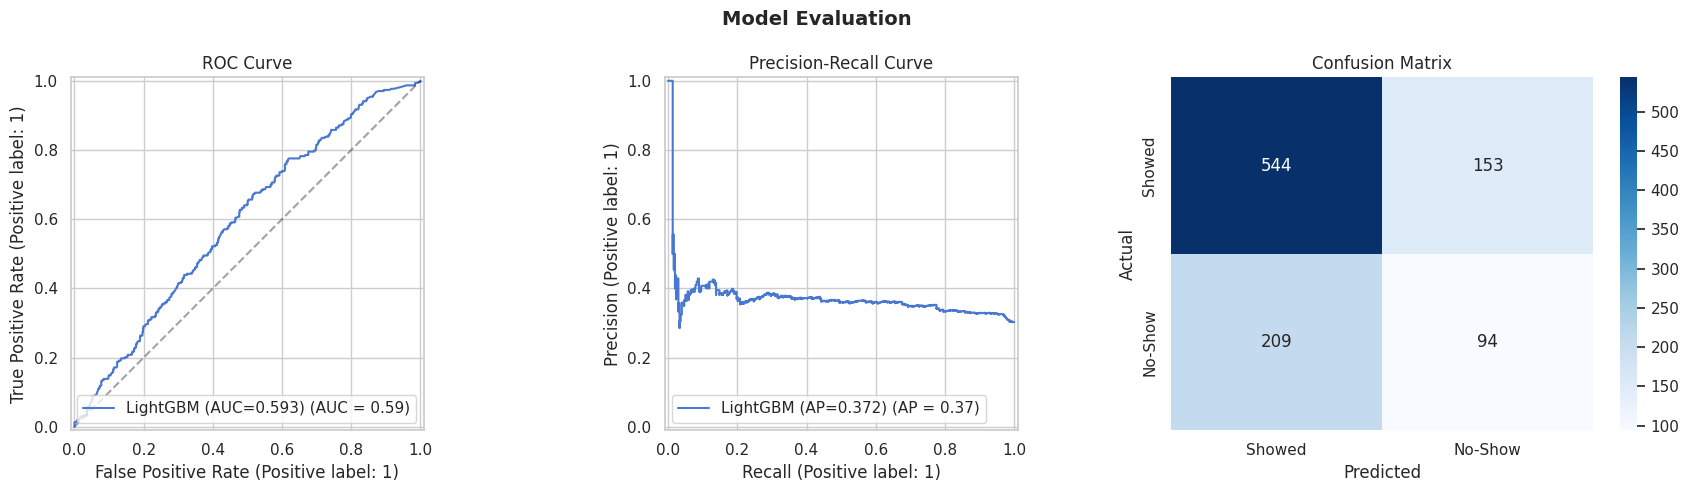

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Evaluation', fontsize=14, fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0], name=f'LightGBM (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('ROC Curve')

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], name=f'LightGBM (AP={ap:.3f})')
axes[1].set_title('Precision-Recall Curve')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Showed','No-Show'], yticklabels=['Showed','No-Show'])
axes[2].set_title('Confusion Matrix')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

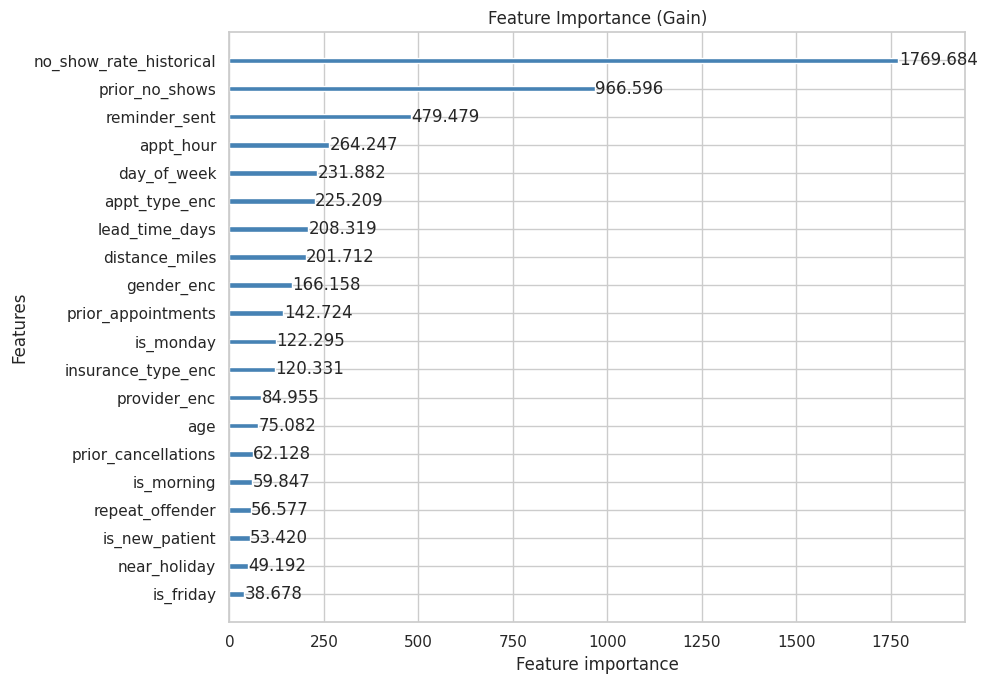

In [12]:
# LightGBM native feature importance
fig, ax = plt.subplots(figsize=(10, 7))
lgb.plot_importance(model, ax=ax, max_num_features=20, importance_type='gain',
                    title='Feature Importance (Gain)', color='steelblue')
plt.tight_layout()
plt.show()

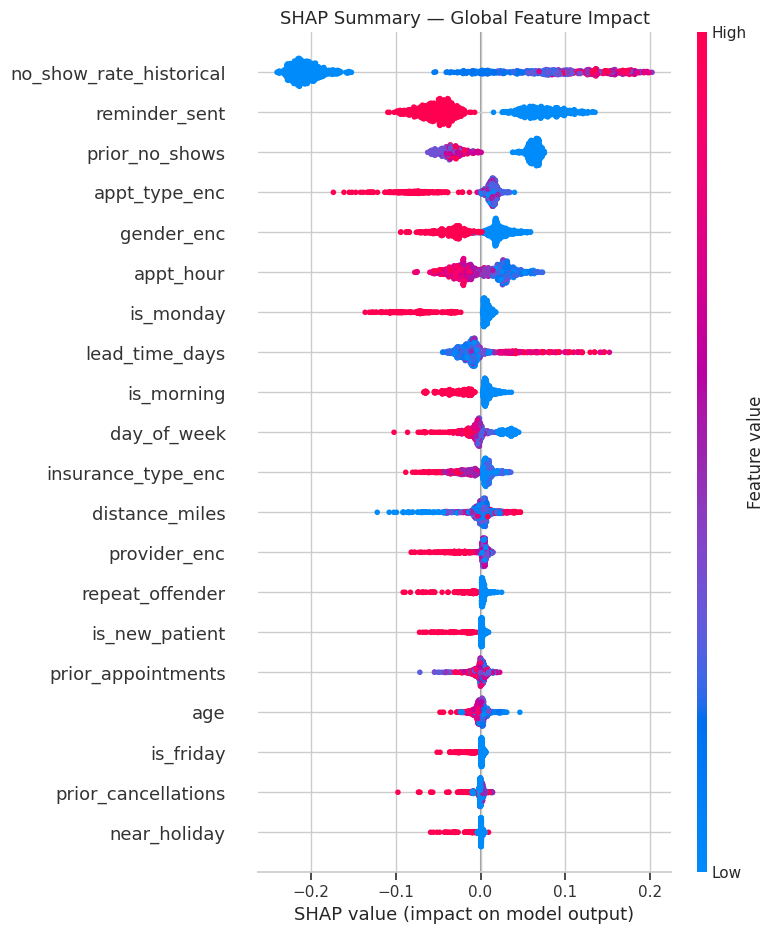

In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Global SHAP summary
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Summary — Global Feature Impact', fontsize=13)
plt.tight_layout()
plt.show()

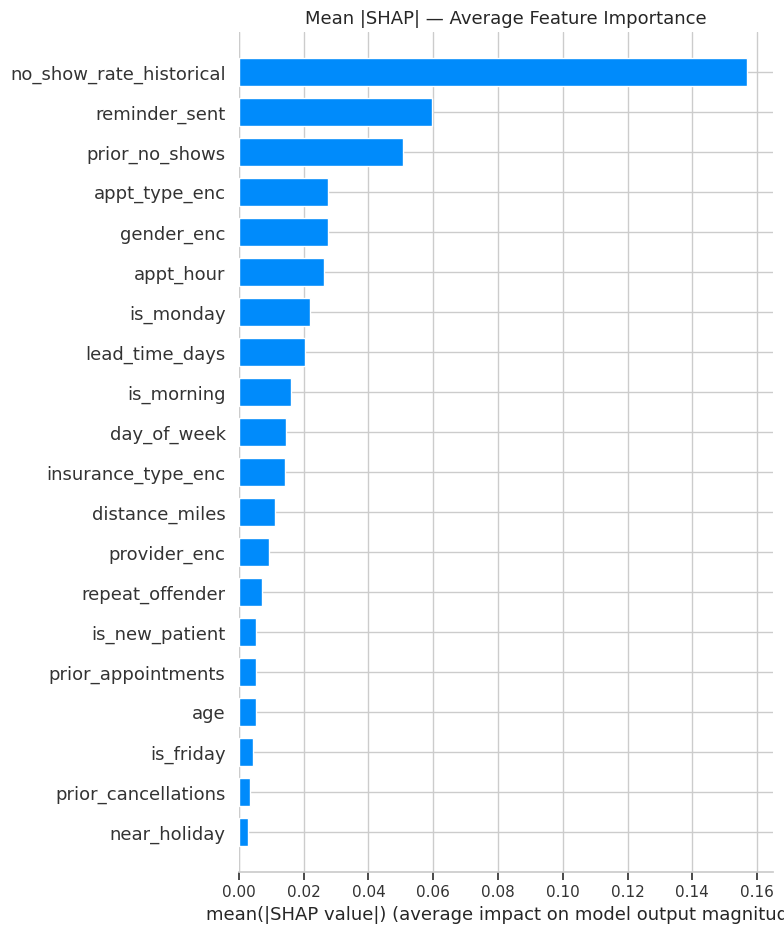

In [14]:
# SHAP bar plot — mean absolute impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, plot_type='bar', show=False)
plt.title('Mean |SHAP| — Average Feature Importance', fontsize=13)
plt.tight_layout()
plt.show()

Highest risk appointment in test set:
age                        66.000
gender_enc                  0.000
insurance_type_enc          2.000
distance_miles              0.900
prior_no_shows              1.000
prior_appointments          2.000
prior_cancellations         0.000
no_show_rate_historical     0.333
appt_type_enc               1.000
lead_time_days             14.000
day_of_week                 1.000
appt_hour                   8.000
near_holiday                0.000
reminder_sent               0.000
provider_enc                1.000
is_monday                   0.000
is_friday                   0.000
is_morning                  1.000
is_new_patient              0.000
high_lead_time              0.000
far_from_practice           0.000
repeat_offender             0.000
Name: 2689, dtype: float64

Predicted no-show probability: 59.0%
Actual outcome: No-Show


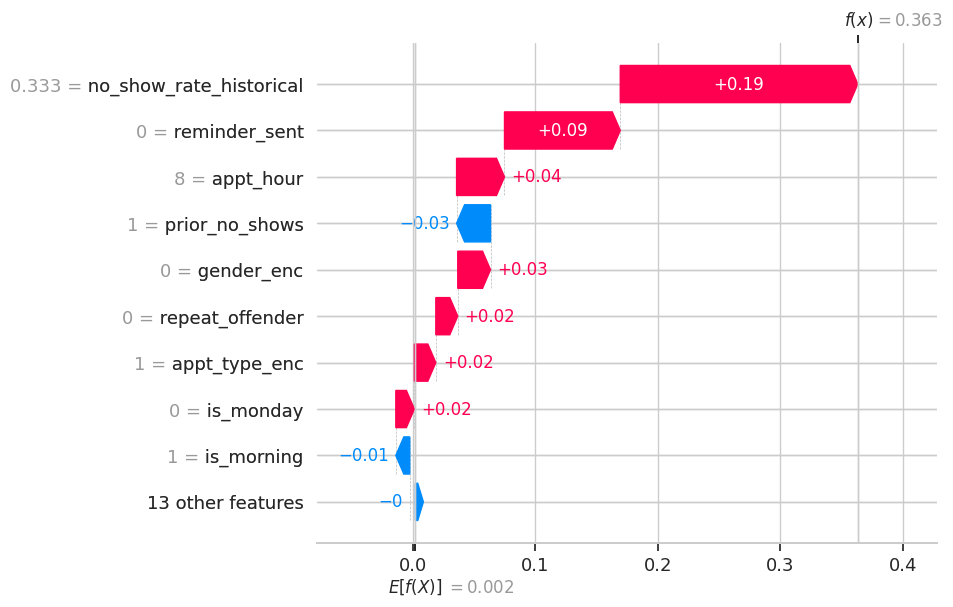

In [15]:
# Individual prediction explanation — highest risk appointment
highest_risk_idx = np.argmax(y_pred_proba)
print(f'Highest risk appointment in test set:')
print(X_test.iloc[highest_risk_idx])
print(f'\nPredicted no-show probability: {y_pred_proba[highest_risk_idx]:.1%}')
print(f'Actual outcome: {"No-Show" if y_test.iloc[highest_risk_idx]==1 else "Showed"}')

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[highest_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[highest_risk_idx].values,
        feature_names=FEATURES
    )
)

In [16]:
def assign_risk_tier(prob):
    if prob >= 0.50:
        return 'HIGH'
    elif prob >= 0.30:
        return 'MEDIUM'
    else:
        return 'LOW'

def recommended_action(tier):
    actions = {
        'HIGH':   '📞 Confirmation call today',
        'MEDIUM': '📱 Send SMS reminder',
        'LOW':    '✅ No action needed'
    }
    return actions[tier]

# Build the daily worklist
worklist = X_test.copy()
worklist['no_show_probability'] = y_pred_proba.round(3)
worklist['risk_tier'] = worklist['no_show_probability'].apply(assign_risk_tier)
worklist['recommended_action'] = worklist['risk_tier'].apply(recommended_action)
worklist['actual_outcome'] = y_test.values

# Tier distribution
tier_counts = worklist['risk_tier'].value_counts()
print('=== Risk Tier Distribution ===')
print(tier_counts)
print(f'\nNo-show rate by tier:')
print(worklist.groupby('risk_tier')['actual_outcome'].mean().apply(lambda x: f'{x:.1%}'))

# Preview worklist — sorted by risk
tier_order = {'HIGH': 0, 'MEDIUM': 1, 'LOW': 2}
worklist_sorted = worklist.sort_values('no_show_probability', ascending=False)
print('\n=== Sample Daily Worklist (Top 10 High Risk) ===')
worklist_sorted[worklist_sorted.risk_tier=='HIGH'][[
    'no_show_probability', 'risk_tier', 'recommended_action',
    'prior_no_shows', 'lead_time_days', 'insurance_type_enc'
]].head(10)

=== Risk Tier Distribution ===
risk_tier
MEDIUM    749
HIGH      251
Name: count, dtype: int64

No-show rate by tier:
risk_tier
HIGH      38.2%
MEDIUM    27.6%
Name: actual_outcome, dtype: object

=== Sample Daily Worklist (Top 10 High Risk) ===


,no_show_probability,risk_tier,recommended_action,prior_no_shows,lead_time_days,insurance_type_enc
2689,0.590,HIGH,📞 Confirmation call today,1,14,2
592,0.586,HIGH,📞 Confirmation call today,1,60,1
1781,0.582,HIGH,📞 Confirmation call today,1,45,0
730,0.581,HIGH,📞 Confirmation call today,1,1,0
2627,0.580,HIGH,📞 Confirmation call today,2,14,0
568,0.580,HIGH,📞 Confirmation call today,4,21,0
4564,0.580,HIGH,📞 Confirmation call today,2,45,1
1657,0.580,HIGH,📞 Confirmation call today,3,60,0
544,0.576,HIGH,📞 Confirmation call today,1,14,0
3281,0.571,HIGH,📞 Confirmation call today,1,1,2


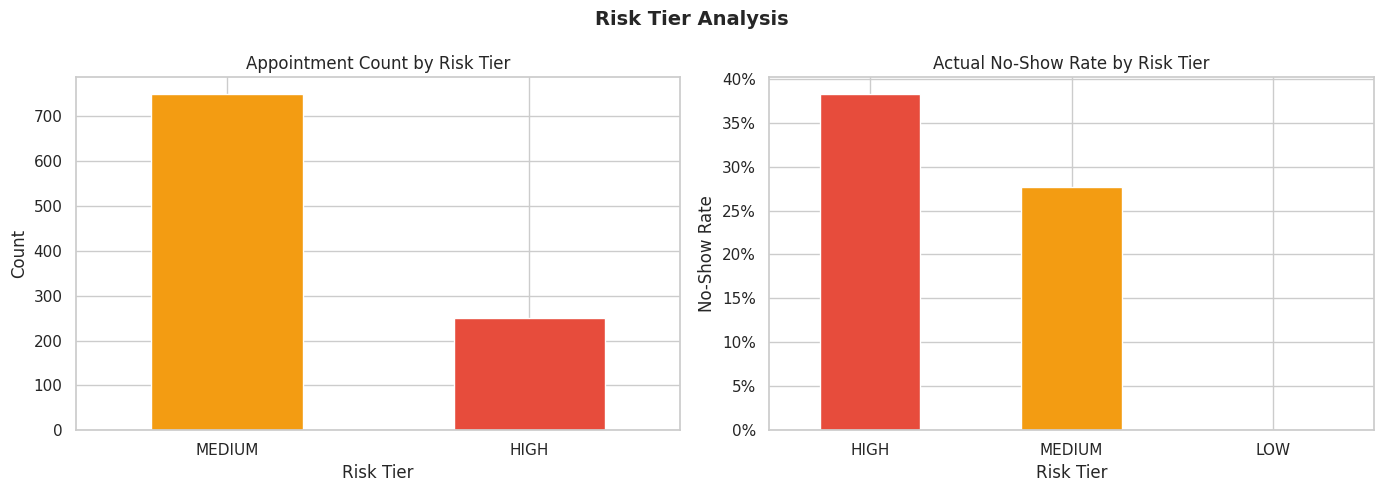

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Risk Tier Analysis', fontsize=14, fontweight='bold')

# Tier distribution
colors = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#2ecc71'}
tier_counts.plot(kind='bar', ax=axes[0], color=[colors[t] for t in tier_counts.index])
axes[0].set_title('Appointment Count by Risk Tier')
axes[0].set_xlabel('Risk Tier')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Actual no-show rate by tier
tier_ns = worklist.groupby('risk_tier')['actual_outcome'].mean().reindex(['HIGH','MEDIUM','LOW'])
tier_ns.plot(kind='bar', ax=axes[1], color=[colors[t] for t in tier_ns.index])
axes[1].set_title('Actual No-Show Rate by Risk Tier')
axes[1].set_xlabel('Risk Tier')
axes[1].set_ylabel('No-Show Rate')
axes[1].tick_params(axis='x', rotation=0)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

In [18]:
# Reconstruct test set with original categorical values for audit
test_with_cats = df.iloc[y_test.index].copy()
test_with_cats['pred_proba'] = y_pred_proba
test_with_cats['pred_label'] = y_pred
test_with_cats['risk_tier'] = worklist['risk_tier'].values

print('=== BIAS AUDIT ===')
print('\n--- AUC by Insurance Type ---')
for ins in test_with_cats['insurance_type'].unique():
    subset = test_with_cats[test_with_cats['insurance_type'] == ins]
    if subset['no_show'].nunique() > 1:
        auc_sub = roc_auc_score(subset['no_show'], subset['pred_proba'])
        ns_rate  = subset['no_show'].mean()
        high_flag_rate = (subset['risk_tier'] == 'HIGH').mean()
        print(f'  {ins:15s} | AUC: {auc_sub:.3f} | Actual NS Rate: {ns_rate:.1%} | High-Risk Flag Rate: {high_flag_rate:.1%}')

print('\n--- AUC by Age Group ---')
test_with_cats['age_group'] = pd.cut(test_with_cats['age'], bins=[17,30,45,60,100], labels=['18-30','31-45','46-60','60+'])
for grp in ['18-30','31-45','46-60','60+']:
    subset = test_with_cats[test_with_cats['age_group'] == grp]
    if subset['no_show'].nunique() > 1:
        auc_sub = roc_auc_score(subset['no_show'], subset['pred_proba'])
        ns_rate  = subset['no_show'].mean()
        print(f'  Age {grp:6s} | AUC: {auc_sub:.3f} | Actual NS Rate: {ns_rate:.1%}')

print('\n--- AUC by Gender ---')
for g in ['M', 'F']:
    subset = test_with_cats[test_with_cats['gender'] == g]
    auc_sub = roc_auc_score(subset['no_show'], subset['pred_proba'])
    print(f'  Gender {g} | AUC: {auc_sub:.3f} | Actual NS Rate: {subset["no_show"].mean():.1%}')

print('\n⚠️  Flag: If Medicaid high-risk flag rate >> Medicaid actual no-show rate, review feature weights.')

=== BIAS AUDIT ===

--- AUC by Insurance Type ---
  Medicare        | AUC: 0.581 | Actual NS Rate: 24.2% | High-Risk Flag Rate: 19.6%
  Self-Pay        | AUC: 0.697 | Actual NS Rate: 39.0% | High-Risk Flag Rate: 22.0%
  Commercial      | AUC: 0.588 | Actual NS Rate: 25.3% | High-Risk Flag Rate: 28.2%
  Medicaid        | AUC: 0.519 | Actual NS Rate: 39.5% | High-Risk Flag Rate: 27.6%
  Other           | AUC: 0.749 | Actual NS Rate: 22.9% | High-Risk Flag Rate: 16.7%

--- AUC by Age Group ---
  Age 18-30  | AUC: 0.615 | Actual NS Rate: 29.8%
  Age 31-45  | AUC: 0.557 | Actual NS Rate: 28.3%
  Age 46-60  | AUC: 0.565 | Actual NS Rate: 34.7%
  Age 60+    | AUC: 0.623 | Actual NS Rate: 28.8%

--- AUC by Gender ---
  Gender M | AUC: 0.586 | Actual NS Rate: 29.9%
  Gender F | AUC: 0.596 | Actual NS Rate: 30.6%

⚠️  Flag: If Medicaid high-risk flag rate >> Medicaid actual no-show rate, review feature weights.


In [19]:
# Practice parameters (adjust per client)
DAILY_APPOINTMENTS   = 30     # appointments per day
AVG_VISIT_REVENUE    = 150    # dollars per visit
WORKING_DAYS         = 250    # days per year
INTERVENTION_SUCCESS = 0.35   # % of high-risk patients converted with outreach

# From model
high_risk_rate = (worklist['risk_tier'] == 'HIGH').mean()
high_risk_precision = worklist[worklist['risk_tier']=='HIGH']['actual_outcome'].mean()

# Calculations
daily_high_risk      = DAILY_APPOINTMENTS * high_risk_rate
daily_true_positives = daily_high_risk * high_risk_precision
daily_recovered      = daily_true_positives * INTERVENTION_SUCCESS
annual_revenue       = daily_recovered * AVG_VISIT_REVENUE * WORKING_DAYS

print('=== ESTIMATED ANNUAL REVENUE IMPACT ===')
print(f'Daily appointments:         {DAILY_APPOINTMENTS}')
print(f'High-risk flagged daily:    {daily_high_risk:.1f} ({high_risk_rate:.1%} of schedule)')
print(f'True positives daily:       {daily_true_positives:.1f} (precision={high_risk_precision:.1%})')
print(f'Recovered visits daily:     {daily_recovered:.1f} ({INTERVENTION_SUCCESS:.0%} intervention success)')
print(f'Annual revenue recovered:   ${annual_revenue:,.0f}')
print(f'\nColossal AI monthly fee:    $399')
print(f'Annual fee:                 $4,788')
print(f'ROI for practice:           {annual_revenue/4788:.0f}x')

=== ESTIMATED ANNUAL REVENUE IMPACT ===
Daily appointments:         30
High-risk flagged daily:    7.5 (25.1% of schedule)
True positives daily:       2.9 (precision=38.2%)
Recovered visits daily:     1.0 (35% intervention success)
Annual revenue recovered:   $37,800

Colossal AI monthly fee:    $399
Annual fee:                 $4,788
ROI for practice:           8x


In [20]:
model.save_model('no_show_model_v1.txt')
print('✅ Model saved: no_show_model_v1.txt')

# Save feature list for inference
import json
with open('feature_list.json', 'w') as f:
    json.dump(FEATURES, f)
print('✅ Feature list saved: feature_list.json')

print(f'\n=== Final Model Summary ===')
print(f'AUC-ROC:              {auc:.4f}')
print(f'Average Precision:    {ap:.4f}')
print(f'Training records:     {X_train_sm.shape[0]:,} (after SMOTE)')
print(f'Test records:         {X_test.shape[0]:,}')
print(f'Features:             {len(FEATURES)}')
print(f'Best iteration:       {model.best_iteration}')
print(f'\n🚀 Ready for Elation sandbox integration.')

✅ Model saved: no_show_model_v1.txt
✅ Feature list saved: feature_list.json

=== Final Model Summary ===
AUC-ROC:              0.5932
Average Precision:    0.3715
Training records:     5,578 (after SMOTE)
Test records:         1,000
Features:             22
Best iteration:       7

🚀 Ready for Elation sandbox integration.
